# 04e — CLEAR Peptide Counterfactual Optimization

## Obiettivo

Questo notebook applica un adattamento di **CLEAR** al peptide lead:

```text
F0010 — IGERCQYRDLK
```

L'oracolo differenziabile è quello addestrato nel notebook 04d.

Il notebook:

1. carica GNN, scaler e configurazione del 04d;
2. carica i vincoli posizionali del 04c;
3. verifica che la predizione del seed coincida con quella salvata;
4. ottimizza distribuzioni categoriche sui residui;
5. impone:
   - lunghezza fissa;
   - massimo 1–2 sostituzioni;
   - posizioni protette bloccate;
   - sostituzioni ammesse dal 04c;
6. proietta le soluzioni soft su sequenze valide;
7. completa la ricerca con un beam search guidato dall'oracolo;
8. distingue:
   - candidati già presenti nel dataset 04c;
   - candidati nuovi;
9. calcola minimalità, miglioramento predetto e plausibilità locale;
10. esporta un pannello di candidati da validare con FoldX e Rosetta.

## Interpretazione

CLEAR non dimostra che un peptide leghi meglio.  
Produce **ipotesi controfattuali locali e interpretabili** secondo l'oracolo del 04d.  
La conferma richiede una successiva valutazione strutturale.


## 1. Dipendenze

```bash
pip install pandas numpy matplotlib torch joblib
```


In [1]:
from pathlib import Path
from itertools import combinations, product
from collections import Counter
import json
import math
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

print("PyTorch:", torch.__version__)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)


PyTorch: 2.2.1
Device: mps


## 2. Configurazione


In [27]:
RANDOM_SEED = 20260806

OUTPUT_DIR = Path("outputs")
DATASET_04C_DIR = OUTPUT_DIR / "clear_local_peptide_dataset_04c"
ORACLE_04D_DIR = OUTPUT_DIR / "clear_peptide_oracle_04d"

MODEL_PATH = (
    ORACLE_04D_DIR
    / "models"
    / "clear_peptide_oracle_gnn.pt"
)
TARGET_SCALER_PATH = (
    ORACLE_04D_DIR
    / "models"
    / "target_scaler.joblib"
)
ORACLE_CONFIG_PATH = (
    ORACLE_04D_DIR
    / "models"
    / "oracle_config.json"
)

POSITION_CONSTRAINTS_CSV = (
    DATASET_04C_DIR
    / "library"
    / "clear_position_constraints.csv"
)
LOCAL_LIBRARY_CSV = (
    DATASET_04C_DIR
    / "library"
    / "clear_local_variant_library.csv"
)
LABELED_DATASET_CSV = (
    DATASET_04C_DIR
    / "clear_local_peptide_variant_dataset_labeled.csv"
)

CLEAR_DIR = OUTPUT_DIR / "clear_peptide_counterfactuals_04e"
REPORT_DIR = CLEAR_DIR / "reports"
VALIDATION_DIR = CLEAR_DIR / "validation_panel"

for directory in [CLEAR_DIR, REPORT_DIR, VALIDATION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)


# Vincoli CLEAR
MAX_MUTATIONS = 2
MIN_PREDICTED_IMPROVEMENT = 0.005
TOP_N_FINAL = 20
TOP_N_NEW_FOR_VALIDATION = 10

# Ottimizzazione soft
N_RESTARTS = 40
OPTIMIZATION_STEPS = 300
LEARNING_RATE = 0.08
TEMPERATURE_START = 1.5
TEMPERATURE_END = 0.15

LAMBDA_DISTANCE = 0.02
LAMBDA_ENTROPY = 0.01
LAMBDA_INVALID_MASS = 5.0
LAMBDA_EXCESS_MUTATIONS = 2.0

# Beam search
BEAM_WIDTH = 80
BEAM_TOP_PER_STATE = 12

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Device:", DEVICE)
print("Modello:", MODEL_PATH.resolve())
print("Output:", CLEAR_DIR.resolve())

Device: mps
Device: mps
Modello: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_oracle_04d/models/clear_peptide_oracle_gnn.pt
Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e


## 3. Controllo degli input


In [28]:
required_paths = [
    MODEL_PATH,
    TARGET_SCALER_PATH,
    ORACLE_CONFIG_PATH,
    POSITION_CONSTRAINTS_CSV,
    LOCAL_LIBRARY_CSV,
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "File mancanti:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

print("Tutti gli input necessari sono disponibili.")

Tutti gli input necessari sono disponibili.


## 4. Ricostruzione della GNN del 04d


In [29]:
class PeptideOracleGNN(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        message_passing_steps=3,
        dropout=0.2,
        adjacency=None,
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_dim,
            hidden_dim,
        )

        self.message_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim)
            for _ in range(message_passing_steps)
        ])

        self.update_layers = nn.ModuleList([
            nn.Linear(hidden_dim * 2, hidden_dim)
            for _ in range(message_passing_steps)
        ])

        self.norm_layers = nn.ModuleList([
            nn.LayerNorm(hidden_dim)
            for _ in range(message_passing_steps)
        ])

        self.dropout = nn.Dropout(dropout)

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

        if adjacency is None:
            raise ValueError("Adjacency richiesta.")

        adjacency = torch.tensor(
            adjacency,
            dtype=torch.float32,
        )
        self.register_buffer("adjacency", adjacency)

    def forward(self, x):
        h = torch.relu(
            self.input_projection(x)
        )

        for message_layer, update_layer, norm_layer in zip(
            self.message_layers,
            self.update_layers,
            self.norm_layers,
        ):
            messages = torch.einsum(
                "ij,bjh->bih",
                self.adjacency,
                h,
            )
            messages = torch.relu(
                message_layer(messages)
            )

            updated = torch.cat(
                [h, messages],
                dim=-1,
            )
            updated = torch.relu(
                update_layer(updated)
            )
            updated = self.dropout(updated)

            h = norm_layer(h + updated)

        graph_embedding = h.mean(dim=1)

        return self.regressor(
            graph_embedding
        ).squeeze(-1)

## 5. Caricamento dell'oracolo e dei metadati


In [30]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
)

target_scaler = joblib.load(
    TARGET_SCALER_PATH
)

oracle_config = json.loads(
    ORACLE_CONFIG_PATH.read_text(
        encoding="utf-8"
    )
)

AA_ALPHABET = list(checkpoint["aa_alphabet"])
AA_TO_INDEX = {
    aa: index
    for index, aa in enumerate(AA_ALPHABET)
}

SEED_SEQUENCE = checkpoint["seed_sequence"]
SEQUENCE_LENGTH = int(
    checkpoint["sequence_length"]
)
TARGET_COLUMN = checkpoint["target_column"]
HIGHER_IS_BETTER = bool(
    checkpoint["higher_is_better"]
)
SEED_TARGET_VALUE = float(
    checkpoint["seed_target_value"]
)
SAVED_SEED_PREDICTION = float(
    checkpoint["seed_prediction"]
)

POSITION_FEATURES = np.asarray(
    checkpoint["position_features"],
    dtype=np.float32,
)
PROPERTY_MEAN = np.asarray(
    checkpoint["property_mean"],
    dtype=np.float32,
)
PROPERTY_STD = np.asarray(
    checkpoint["property_std"],
    dtype=np.float32,
)
CHAIN_ADJACENCY = np.asarray(
    checkpoint["chain_adjacency"],
    dtype=np.float32,
)

model = PeptideOracleGNN(
    input_dim=int(checkpoint["input_dim"]),
    hidden_dim=int(checkpoint["hidden_dim"]),
    message_passing_steps=int(
        checkpoint["message_passing_steps"]
    ),
    dropout=float(checkpoint["dropout"]),
    adjacency=CHAIN_ADJACENCY,
).to(DEVICE)

model.load_state_dict(
    checkpoint["model_state_dict"]
)
model.eval()

for parameter in model.parameters():
    parameter.requires_grad_(False)

print("Seed:", SEED_SEQUENCE)
print("Target:", TARGET_COLUMN)
print("Higher is better:", HIGHER_IS_BETTER)
print("Predizione seed salvata:", SAVED_SEED_PREDICTION)

Seed: IGERCQYRDLK
Target: oracle_target_composite_preliminary
Higher is better: True
Predizione seed salvata: 0.7459297705252568


## 6. Proprietà amminoacidiche e codifica differenziabile

La codifica deve essere identica a quella usata nel 04d.


In [31]:
AA_PROPERTIES = {
    "A": [1.8, 88.6, 0, 0, 0],
    "C": [2.5, 108.5, 0, 0, 0],
    "D": [-3.5, 111.1, -1, 1, 0],
    "E": [-3.5, 138.4, -1, 1, 0],
    "F": [2.8, 189.9, 0, 0, 1],
    "G": [-0.4, 60.1, 0, 0, 0],
    "H": [-3.2, 153.2, 0.1, 1, 1],
    "I": [4.5, 166.7, 0, 0, 0],
    "K": [-3.9, 168.6, 1, 1, 0],
    "L": [3.8, 166.7, 0, 0, 0],
    "M": [1.9, 162.9, 0, 0, 0],
    "N": [-3.5, 114.1, 0, 1, 0],
    "P": [-1.6, 112.7, 0, 0, 0],
    "Q": [-3.5, 143.8, 0, 1, 0],
    "R": [-4.5, 173.4, 1, 1, 0],
    "S": [-0.8, 89.0, 0, 1, 0],
    "T": [-0.7, 116.1, 0, 1, 0],
    "V": [4.2, 140.0, 0, 0, 0],
    "W": [-0.9, 227.8, 0, 0, 1],
    "Y": [-1.3, 193.6, 0, 1, 1],
}

PROPERTY_MATRIX = np.array(
    [
        AA_PROPERTIES[aa]
        for aa in AA_ALPHABET
    ],
    dtype=np.float32,
)

PROPERTY_MATRIX_STANDARDIZED = (
    PROPERTY_MATRIX - PROPERTY_MEAN
) / PROPERTY_STD

property_tensor = torch.tensor(
    PROPERTY_MATRIX_STANDARDIZED,
    dtype=torch.float32,
    device=DEVICE,
)

position_feature_tensor = torch.tensor(
    POSITION_FEATURES,
    dtype=torch.float32,
    device=DEVICE,
)


def one_hot_sequence(sequence):
    matrix = np.zeros(
        (SEQUENCE_LENGTH, len(AA_ALPHABET)),
        dtype=np.float32,
    )

    for position, aa in enumerate(sequence):
        matrix[position, AA_TO_INDEX[aa]] = 1.0

    return matrix


def probabilities_to_node_features(probabilities):
    expected_properties = (
        probabilities @ property_tensor
    )

    position_batch = position_feature_tensor.unsqueeze(0).expand(
        probabilities.shape[0],
        -1,
        -1,
    )

    return torch.cat(
        [
            probabilities,
            expected_properties,
            position_batch,
        ],
        dim=-1,
    )


def predict_probabilities_scaled(probabilities):
    features = probabilities_to_node_features(
        probabilities
    )
    return model(features)


def inverse_scale(values):
    values = np.asarray(values).reshape(-1, 1)

    return target_scaler.inverse_transform(
        values
    ).ravel()


def predict_sequences(sequences):
    probabilities = torch.tensor(
        np.stack([
            one_hot_sequence(sequence)
            for sequence in sequences
        ]),
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        scaled = predict_probabilities_scaled(
            probabilities
        ).cpu().numpy()

    return inverse_scale(scaled)

## 7. Verifica di compatibilità con il 04d


In [32]:
seed_prediction = float(
    predict_sequences([SEED_SEQUENCE])[0]
)

print("Predizione seed ricalcolata:", seed_prediction)
print("Predizione seed salvata:", SAVED_SEED_PREDICTION)
print(
    "Differenza assoluta:",
    abs(seed_prediction - SAVED_SEED_PREDICTION),
)

if not np.isclose(
    seed_prediction,
    SAVED_SEED_PREDICTION,
    atol=1e-5,
):
    raise RuntimeError(
        "La ricostruzione dell'oracolo non coincide con il 04d."
    )

print("Oracolo ricostruito correttamente.")

Predizione seed ricalcolata: 0.7459297776222229
Predizione seed salvata: 0.7459297705252568
Differenza assoluta: 7.096966125885729e-09
Oracolo ricostruito correttamente.


## 8. Vincoli posizionali del 04c


In [33]:
position_constraints = pd.read_csv(
    POSITION_CONSTRAINTS_CSV
)

required_constraint_columns = {
    "sequence_position_1based",
    "wildtype_aa",
    "position_class",
    "allowed_substitutions",
}

missing = (
    required_constraint_columns
    - set(position_constraints.columns)
)

if missing:
    raise ValueError(
        "Colonne vincoli mancanti: "
        + ", ".join(sorted(missing))
    )

position_constraints = position_constraints.sort_values(
    "sequence_position_1based"
).reset_index(drop=True)

if len(position_constraints) != SEQUENCE_LENGTH:
    raise ValueError(
        "Numero di posizioni nei vincoli non coerente."
    )

display(position_constraints)

,sequence_position_1based,chain,resseq,wildtype_aa,is_hotspot,alanine_scan_ddG_kcal_mol,position_class,allowed_substitutions,n_allowed_substitutions
0,1,D,38,I,False,1.419390,mutable_non_hotspot,AFLMTV,6
1,2,D,39,G,True,5.876590,protected_hotspot,NaN,0
2,3,D,40,E,False,1.489250,mutable_non_hotspot,DKNQR,5
3,4,D,41,R,True,5.734550,protected_hotspot,NaN,0
4,5,D,42,C,False,NaN,mutable_non_hotspot,ST,2
5,6,D,43,Q,True,2.515570,conservative_hotspot,ENRT,4
6,7,D,44,Y,True,3.370680,conservative_hotspot,FHTW,4
7,8,D,45,R,True,2.002810,conservative_hotspot,HKQ,3
8,9,D,46,D,False,0.017737,mutable_non_hotspot,ENQ,3
9,10,D,47,L,True,3.543710,conservative_hotspot,AFIMTV,6


In [34]:
allowed_mask = np.zeros(
    (SEQUENCE_LENGTH, len(AA_ALPHABET)),
    dtype=np.float32,
)

allowed_by_position = {}
position_classes = {}

for row in position_constraints.itertuples(index=False):
    position_index = int(
        row.sequence_position_1based
    ) - 1
    wildtype = row.wildtype_aa
    position_class = row.position_class

    allowed = {wildtype}

    text = str(row.allowed_substitutions)

    if text.lower() != "nan":
        allowed.update(
            aa for aa in text
            if aa in AA_TO_INDEX
        )

    if position_class == "protected_hotspot":
        allowed = {wildtype}

    allowed_by_position[position_index] = sorted(allowed)
    position_classes[position_index] = position_class

    for aa in allowed:
        allowed_mask[
            position_index,
            AA_TO_INDEX[aa],
        ] = 1.0

allowed_mask_tensor = torch.tensor(
    allowed_mask,
    dtype=torch.float32,
    device=DEVICE,
)

seed_indices = torch.tensor(
    [
        AA_TO_INDEX[aa]
        for aa in SEED_SEQUENCE
    ],
    dtype=torch.long,
    device=DEVICE,
)

constraint_summary = pd.DataFrame([
    {
        "position": position + 1,
        "wildtype": SEED_SEQUENCE[position],
        "position_class": position_classes[position],
        "allowed": "".join(
            allowed_by_position[position]
        ),
        "n_allowed": len(
            allowed_by_position[position]
        ),
    }
    for position in range(SEQUENCE_LENGTH)
])

display(constraint_summary)

,position,wildtype,position_class,allowed,n_allowed
0,1,I,mutable_non_hotspot,AFILMTV,7
1,2,G,protected_hotspot,G,1
2,3,E,mutable_non_hotspot,DEKNQR,6
3,4,R,protected_hotspot,R,1
4,5,C,mutable_non_hotspot,CST,3
5,6,Q,conservative_hotspot,ENQRT,5
6,7,Y,conservative_hotspot,FHTWY,5
7,8,R,conservative_hotspot,HKQR,4
8,9,D,mutable_non_hotspot,DENQ,4
9,10,L,conservative_hotspot,AFILMTV,7


## 9. Funzioni di validità e minimalità


In [35]:
def hamming_distance(sequence_a, sequence_b):
    return sum(
        aa != bb
        for aa, bb in zip(sequence_a, sequence_b)
    )


def mutation_details(sequence):
    details = []

    for index, (wildtype, mutant) in enumerate(
        zip(SEED_SEQUENCE, sequence)
    ):
        if wildtype != mutant:
            details.append({
                "sequence_position_1based": index + 1,
                "wildtype_aa": wildtype,
                "mutant_aa": mutant,
                "position_class": (
                    position_classes[index]
                ),
            })

    return details


def mutation_label(sequence):
    return ";".join(
        f"{item['wildtype_aa']}"
        f"{item['sequence_position_1based']}"
        f"{item['mutant_aa']}"
        for item in mutation_details(sequence)
    )


def sequence_is_valid(sequence):
    if len(sequence) != SEQUENCE_LENGTH:
        return False, "WRONG_LENGTH"

    mutations = mutation_details(sequence)

    if len(mutations) > MAX_MUTATIONS:
        return False, "TOO_MANY_MUTATIONS"

    for index, aa in enumerate(sequence):
        if aa not in allowed_by_position[index]:
            return False, f"DISALLOWED_AA_POS_{index + 1}"

    return True, "PASS"


def improvement_vs_seed(prediction):
    if HIGHER_IS_BETTER:
        return prediction - seed_prediction

    return seed_prediction - prediction

## 10. Ottimizzazione CLEAR soft-categorical

Per ogni restart:

1. i logits partono vicini al seed;
2. le categorie non ammesse vengono mascherate;
3. la temperatura viene ridotta progressivamente;
4. l'obiettivo favorisce:
   - miglioramento del target;
   - poche modifiche;
   - bassa entropia;
   - rispetto dei vincoli;
5. a intervalli regolari la soluzione viene proiettata su una sequenza hard.

La distanza soft dal seed è:

```text
somma sulle posizioni di (1 - probabilità del residuo originale)
```


In [36]:
def temperature_at_step(step):
    fraction = step / max(
        OPTIMIZATION_STEPS - 1,
        1,
    )

    return (
        TEMPERATURE_START
        * (
            TEMPERATURE_END
            / TEMPERATURE_START
        ) ** fraction
    )


def hard_project(probabilities):
    probabilities = probabilities.detach().cpu().numpy()

    sequence = []

    for position in range(SEQUENCE_LENGTH):
        allowed_indices = [
            AA_TO_INDEX[aa]
            for aa in allowed_by_position[position]
        ]

        best_index = max(
            allowed_indices,
            key=lambda index: probabilities[
                position,
                index,
            ],
        )

        sequence.append(
            AA_ALPHABET[best_index]
        )

    raw_sequence = "".join(sequence)

    mutations = mutation_details(raw_sequence)

    if len(mutations) <= MAX_MUTATIONS:
        return raw_sequence

    ranked_mutations = sorted(
        mutations,
        key=lambda item: probabilities[
            item["sequence_position_1based"] - 1,
            AA_TO_INDEX[item["mutant_aa"]],
        ]
        - probabilities[
            item["sequence_position_1based"] - 1,
            AA_TO_INDEX[item["wildtype_aa"]],
        ],
        reverse=True,
    )

    keep_positions = {
        item["sequence_position_1based"] - 1
        for item in ranked_mutations[:MAX_MUTATIONS]
    }

    projected = list(SEED_SEQUENCE)

    for position in keep_positions:
        projected[position] = raw_sequence[position]

    return "".join(projected)


soft_candidate_records = []

for restart in range(N_RESTARTS):
    logits = torch.full(
        (
            SEQUENCE_LENGTH,
            len(AA_ALPHABET),
        ),
        -2.0,
        dtype=torch.float32,
        device=DEVICE,
        requires_grad=True,
    )

    with torch.no_grad():
        logits[
            torch.arange(SEQUENCE_LENGTH),
            seed_indices,
        ] = 3.0

        noise = 0.15 * torch.randn_like(logits)
        logits.add_(noise)

    optimizer = torch.optim.Adam(
        [logits],
        lr=LEARNING_RATE,
    )

    best_objective = -float("inf")
    best_sequence = SEED_SEQUENCE
    best_step = 0

    for step in range(OPTIMIZATION_STEPS):
        temperature = temperature_at_step(step)

        masked_logits = logits.masked_fill(
            allowed_mask_tensor == 0,
            -1e9,
        )

        probabilities = torch.softmax(
            masked_logits / temperature,
            dim=-1,
        )

        scaled_prediction = (
            predict_probabilities_scaled(
                probabilities.unsqueeze(0)
            )[0]
        )

        seed_probability = probabilities[
            torch.arange(SEQUENCE_LENGTH),
            seed_indices,
        ]

        soft_distance = (
            1.0 - seed_probability
        ).sum()

        entropy = -(
            probabilities
            * torch.log(
                probabilities.clamp_min(1e-9)
            )
        ).sum()

        excess_mutations = torch.relu(
            soft_distance - MAX_MUTATIONS
        )

        invalid_mass = (
            probabilities
            * (1.0 - allowed_mask_tensor)
        ).sum()

        direction = (
            1.0 if HIGHER_IS_BETTER else -1.0
        )

        objective = (
            direction * scaled_prediction
            - LAMBDA_DISTANCE * soft_distance
            - LAMBDA_ENTROPY * entropy
            - LAMBDA_INVALID_MASS * invalid_mass
            - LAMBDA_EXCESS_MUTATIONS * excess_mutations
        )

        loss = -objective

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 10 == 0 or step == OPTIMIZATION_STEPS - 1:
            projected_sequence = hard_project(
                probabilities
            )

            prediction = float(
                predict_sequences(
                    [projected_sequence]
                )[0]
            )

            improvement = improvement_vs_seed(
                prediction
            )

            hard_objective = (
                improvement
                - LAMBDA_DISTANCE
                * hamming_distance(
                    projected_sequence,
                    SEED_SEQUENCE,
                )
            )

            if hard_objective > best_objective:
                best_objective = hard_objective
                best_sequence = projected_sequence
                best_step = step

    prediction = float(
        predict_sequences([best_sequence])[0]
    )

    valid, status = sequence_is_valid(
        best_sequence
    )

    soft_candidate_records.append({
        "source": "soft_clear",
        "restart": restart,
        "best_step": best_step,
        "sequence": best_sequence,
        "prediction": prediction,
        "predicted_improvement_vs_seed": (
            improvement_vs_seed(prediction)
        ),
        "n_mutations": hamming_distance(
            best_sequence,
            SEED_SEQUENCE,
        ),
        "mutation_labels": mutation_label(
            best_sequence
        ),
        "valid": valid,
        "validity_status": status,
        "optimization_objective": best_objective,
    })

soft_candidates = pd.DataFrame(
    soft_candidate_records
)

display(
    soft_candidates.sort_values(
        "predicted_improvement_vs_seed",
        ascending=False,
    ).head(20)
)

,source,restart,best_step,sequence,prediction,predicted_improvement_vs_seed,n_mutations,mutation_labels,valid,validity_status,optimization_objective
0,soft_clear,0,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
1,soft_clear,1,240,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
22,soft_clear,22,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
23,soft_clear,23,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
24,soft_clear,24,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
25,soft_clear,25,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
26,soft_clear,26,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
27,soft_clear,27,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
28,soft_clear,28,30,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971
29,soft_clear,29,40,IGERCQYRELK,0.8089,0.062971,1,D9E,True,PASS,0.042971


## 11. Beam search controfattuale guidato dall'oracolo

La ricerca soft può convergere più volte alla stessa soluzione.  
Il beam search esplora in modo discreto le sostituzioni ammesse, mantenendo la minimalità e usando l'oracolo come score.

Questa fase non sostituisce CLEAR: serve come **hard projection/search** coerente con i vincoli.


In [37]:
def score_sequence(sequence):
    prediction = float(
        predict_sequences([sequence])[0]
    )

    improvement = improvement_vs_seed(
        prediction
    )

    distance = hamming_distance(
        sequence,
        SEED_SEQUENCE,
    )

    objective = (
        improvement
        - LAMBDA_DISTANCE * distance
    )

    return prediction, improvement, objective


beam = [{
    "sequence": SEED_SEQUENCE,
    "prediction": seed_prediction,
    "improvement": 0.0,
    "objective": 0.0,
}]

visited = {SEED_SEQUENCE}
beam_records = []

for depth in range(1, MAX_MUTATIONS + 1):
    expansion_sequences = []

    for state in beam:
        current_sequence = state["sequence"]

        for position in range(SEQUENCE_LENGTH):
            current_aa = current_sequence[position]

            for mutant_aa in allowed_by_position[position]:
                if mutant_aa == current_aa:
                    continue

                candidate = list(current_sequence)
                candidate[position] = mutant_aa
                candidate = "".join(candidate)

                if candidate in visited:
                    continue

                if hamming_distance(
                    candidate,
                    SEED_SEQUENCE,
                ) != depth:
                    continue

                valid, _ = sequence_is_valid(candidate)

                if not valid:
                    continue

                visited.add(candidate)
                expansion_sequences.append(candidate)

    if not expansion_sequences:
        break

    predictions = predict_sequences(
        expansion_sequences
    )

    expansion_records = []

    for sequence, prediction in zip(
        expansion_sequences,
        predictions,
    ):
        prediction = float(prediction)
        improvement = improvement_vs_seed(
            prediction
        )

        objective = (
            improvement
            - LAMBDA_DISTANCE
            * hamming_distance(
                sequence,
                SEED_SEQUENCE,
            )
        )

        expansion_records.append({
            "source": "beam_clear",
            "depth": depth,
            "sequence": sequence,
            "prediction": prediction,
            "predicted_improvement_vs_seed": improvement,
            "n_mutations": hamming_distance(
                sequence,
                SEED_SEQUENCE,
            ),
            "mutation_labels": mutation_label(sequence),
            "valid": True,
            "validity_status": "PASS",
            "optimization_objective": objective,
        })

    expansion_df = pd.DataFrame(
        expansion_records
    ).sort_values(
        [
            "optimization_objective",
            "predicted_improvement_vs_seed",
        ],
        ascending=False,
    )

    beam_records.extend(
        expansion_df.to_dict(orient="records")
    )

    beam = [
        {
            "sequence": row.sequence,
            "prediction": row.prediction,
            "improvement": (
                row.predicted_improvement_vs_seed
            ),
            "objective": (
                row.optimization_objective
            ),
        }
        for row in expansion_df.head(
            BEAM_WIDTH
        ).itertuples(index=False)
    ]

    print(
        f"Profondità {depth}: "
        f"{len(expansion_df)} candidati, "
        f"beam={len(beam)}"
    )

beam_candidates = pd.DataFrame(
    beam_records
)

display(
    beam_candidates.sort_values(
        "predicted_improvement_vs_seed",
        ascending=False,
    ).head(20)
)

Profondità 1: 38 candidati, beam=38
Profondità 2: 634 candidati, beam=80


,source,depth,sequence,prediction,predicted_improvement_vs_seed,n_mutations,mutation_labels,valid,validity_status,optimization_objective
38,beam_clear,2,IGERSQYRELK,0.841685,0.095755,2,C5S;D9E,True,PASS,0.055755
39,beam_clear,2,IGERCQYKELK,0.820839,0.074910,2,R8K;D9E,True,PASS,0.034910
40,beam_clear,2,IGERCEYRELK,0.820120,0.074191,2,Q6E;D9E,True,PASS,0.034191
41,beam_clear,2,IGERCQYRELR,0.813354,0.067425,2,D9E;K11R,True,PASS,0.027425
0,beam_clear,1,IGERCQYRELK,0.808901,0.062971,1,D9E,True,PASS,0.042971
42,beam_clear,2,IGERCQYRELE,0.807465,0.061535,2,D9E;K11E,True,PASS,0.021535
43,beam_clear,2,IGERSEYRDLK,0.807358,0.061428,2,C5S;Q6E,True,PASS,0.021428
44,beam_clear,2,IGERCQYRELQ,0.803391,0.057461,2,D9E;K11Q,True,PASS,0.017461
45,beam_clear,2,IGERSQYKDLK,0.794216,0.048286,2,C5S;R8K,True,PASS,0.008286
46,beam_clear,2,IGERTQYRELK,0.788197,0.042268,2,C5T;D9E,True,PASS,0.002268


## 12. Unione e deduplicazione dei candidati CLEAR


In [38]:
candidate_tables = []

if not soft_candidates.empty:
    candidate_tables.append(
        soft_candidates.copy()
    )

if not beam_candidates.empty:
    candidate_tables.append(
        beam_candidates.copy()
    )

all_candidates = pd.concat(
    candidate_tables,
    ignore_index=True,
)

all_candidates = all_candidates[
    all_candidates["valid"]
].copy()

all_candidates = (
    all_candidates
    .sort_values(
        [
            "predicted_improvement_vs_seed",
            "n_mutations",
            "optimization_objective",
        ],
        ascending=[False, True, False],
    )
    .drop_duplicates("sequence")
    .reset_index(drop=True)
)

all_candidates["counterfactual_success"] = (
    all_candidates[
        "predicted_improvement_vs_seed"
    ] >= MIN_PREDICTED_IMPROVEMENT
)

print("Candidati unici:", len(all_candidates))
print(
    "Controfattuali di successo:",
    int(
        all_candidates[
            "counterfactual_success"
        ].sum()
    ),
)

display(all_candidates.head(30))

Candidati unici: 672
Controfattuali di successo: 36


,source,restart,best_step,sequence,prediction,predicted_improvement_vs_seed,n_mutations,mutation_labels,valid,validity_status,optimization_objective,depth,counterfactual_success
0,beam_clear,NaN,NaN,IGERSQYRELK,0.841685,0.095755,2,C5S;D9E,True,PASS,0.055755,2.0,True
1,beam_clear,NaN,NaN,IGERCQYKELK,0.820839,0.074910,2,R8K;D9E,True,PASS,0.034910,2.0,True
2,beam_clear,NaN,NaN,IGERCEYRELK,0.820120,0.074191,2,Q6E;D9E,True,PASS,0.034191,2.0,True
3,beam_clear,NaN,NaN,IGERCQYRELR,0.813354,0.067425,2,D9E;K11R,True,PASS,0.027425,2.0,True
4,beam_clear,NaN,NaN,IGERCQYRELK,0.808901,0.062971,1,D9E,True,PASS,0.042971,1.0,True
5,beam_clear,NaN,NaN,IGERCQYRELE,0.807465,0.061535,2,D9E;K11E,True,PASS,0.021535,2.0,True
6,beam_clear,NaN,NaN,IGERSEYRDLK,0.807358,0.061428,2,C5S;Q6E,True,PASS,0.021428,2.0,True
7,beam_clear,NaN,NaN,IGERCQYRELQ,0.803391,0.057461,2,D9E;K11Q,True,PASS,0.017461,2.0,True
8,beam_clear,NaN,NaN,IGERSQYKDLK,0.794216,0.048286,2,C5S;R8K,True,PASS,0.008286,2.0,True
9,beam_clear,NaN,NaN,IGERTQYRELK,0.788197,0.042268,2,C5T;D9E,True,PASS,0.002268,2.0,True


## 13. Candidati già osservati e candidati nuovi

Un candidato è considerato “nuovo” quando la sua sequenza non compare nella libreria generata dal 04c.

Questo controllo è fondamentale: il 04e deve poter proporre anche combinazioni non usate per addestrare l'oracolo.


In [39]:
local_library = pd.read_csv(
    LOCAL_LIBRARY_CSV
)

known_sequences = set(
    local_library["sequence"].astype(str)
)

if LABELED_DATASET_CSV.exists():
    labeled_dataset = pd.read_csv(
        LABELED_DATASET_CSV
    )
    labeled_sequences = set(
        labeled_dataset["sequence"].astype(str)
    )
else:
    labeled_dataset = pd.DataFrame()
    labeled_sequences = set()

all_candidates["present_in_04c_library"] = (
    all_candidates["sequence"].isin(
        known_sequences
    )
)
all_candidates["present_in_04c_labeled"] = (
    all_candidates["sequence"].isin(
        labeled_sequences
    )
)
all_candidates["is_novel_sequence"] = (
    ~all_candidates[
        "present_in_04c_library"
    ]
)

novelty_summary = pd.DataFrame({
    "category": [
        "all_unique_candidates",
        "present_in_04c_library",
        "present_in_04c_labeled",
        "novel_sequences",
    ],
    "count": [
        len(all_candidates),
        int(
            all_candidates[
                "present_in_04c_library"
            ].sum()
        ),
        int(
            all_candidates[
                "present_in_04c_labeled"
            ].sum()
        ),
        int(
            all_candidates[
                "is_novel_sequence"
            ].sum()
        ),
    ],
})

display(novelty_summary)

,category,count
0,all_unique_candidates,672
1,present_in_04c_library,538
2,present_in_04c_labeled,538
3,novel_sequences,134


## 14. Supporto locale dell'oracolo

Per ogni candidato viene calcolata la minima distanza di Hamming dalle sequenze etichettate.

- distanza 0: sequenza già etichettata;
- distanza 1: molto vicina ai dati osservati;
- distanza 2: ancora locale, ma più estrapolativa.

CLEAR deve privilegiare candidati con supporto locale elevato.


In [40]:
reference_sequences = (
    labeled_dataset["sequence"].astype(str).tolist()
    if not labeled_dataset.empty
    else local_library["sequence"].astype(str).tolist()
)


def min_distance_to_reference(sequence):
    return min(
        hamming_distance(sequence, reference)
        for reference in reference_sequences
    )


all_candidates[
    "min_hamming_to_labeled_data"
] = all_candidates["sequence"].apply(
    min_distance_to_reference
)

all_candidates["local_support_class"] = pd.cut(
    all_candidates[
        "min_hamming_to_labeled_data"
    ],
    bins=[-0.1, 0.1, 1.1, 2.1, np.inf],
    labels=[
        "observed",
        "strong_local_support",
        "moderate_local_support",
        "weak_support",
    ],
)

display(
    all_candidates[
        [
            "sequence",
            "mutation_labels",
            "predicted_improvement_vs_seed",
            "is_novel_sequence",
            "min_hamming_to_labeled_data",
            "local_support_class",
        ]
    ].head(30)
)

,sequence,mutation_labels,predicted_improvement_vs_seed,is_novel_sequence,min_hamming_to_labeled_data,local_support_class
0,IGERSQYRELK,C5S;D9E,0.095755,False,0,observed
1,IGERCQYKELK,R8K;D9E,0.074910,False,0,observed
2,IGERCEYRELK,Q6E;D9E,0.074191,False,0,observed
3,IGERCQYRELR,D9E;K11R,0.067425,False,0,observed
4,IGERCQYRELK,D9E,0.062971,False,0,observed
5,IGERCQYRELE,D9E;K11E,0.061535,False,0,observed
6,IGERSEYRDLK,C5S;Q6E,0.061428,False,0,observed
7,IGERCQYRELQ,D9E;K11Q,0.057461,False,0,observed
8,IGERSQYKDLK,C5S;R8K,0.048286,False,0,observed
9,IGERTQYRELK,C5T;D9E,0.042268,False,0,observed


## 15. Frequenza delle mutazioni nei migliori controfattuali


In [41]:
successful_candidates = all_candidates[
    all_candidates["counterfactual_success"]
].copy()

top_for_interpretation = successful_candidates.head(
    min(50, len(successful_candidates))
)

mutation_counter = Counter()

for sequence in top_for_interpretation["sequence"]:
    for item in mutation_details(sequence):
        mutation_counter[
            (
                item["wildtype_aa"],
                item["sequence_position_1based"],
                item["mutant_aa"],
            )
        ] += 1

mutation_frequency = pd.DataFrame([
    {
        "mutation": f"{wildtype}{position}{mutant}",
        "wildtype_aa": wildtype,
        "position": position,
        "mutant_aa": mutant,
        "count_in_top_candidates": count,
    }
    for (
        wildtype,
        position,
        mutant,
    ), count in mutation_counter.most_common()
])

display(mutation_frequency.head(30))

,mutation,wildtype_aa,position,mutant_aa,count_in_top_candidates
0,D9E,D,9,E,17
1,C5S,C,5,S,10
2,R8K,R,8,K,7
3,Q6E,Q,6,E,7
4,K11E,K,11,E,5
5,K11R,K,11,R,4
6,D9Q,D,9,Q,3
7,K11Q,K,11,Q,2
8,C5T,C,5,T,2
9,I1T,I,1,T,2


## 16. Ranking finale CLEAR

Il ranking favorisce:

1. miglioramento predetto;
2. minimalità;
3. novità;
4. vicinanza ai dati etichettati.

Il miglioramento predetto resta il criterio principale.


In [42]:
all_candidates["minimality_score"] = (
    1.0 / (
        1.0 + all_candidates["n_mutations"]
    )
)

all_candidates["novelty_bonus"] = (
    all_candidates["is_novel_sequence"]
    .astype(float)
)

all_candidates["support_score"] = (
    1.0 / (
        1.0
        + all_candidates[
            "min_hamming_to_labeled_data"
        ]
    )
)

improvement_values = all_candidates[
    "predicted_improvement_vs_seed"
].astype(float)

if improvement_values.max() > improvement_values.min():
    all_candidates[
        "normalized_predicted_improvement"
    ] = (
        improvement_values
        - improvement_values.min()
    ) / (
        improvement_values.max()
        - improvement_values.min()
    )
else:
    all_candidates[
        "normalized_predicted_improvement"
    ] = 0.0

all_candidates["clear_final_score"] = (
    0.70
    * all_candidates[
        "normalized_predicted_improvement"
    ]
    + 0.15
    * all_candidates["minimality_score"]
    + 0.10
    * all_candidates["support_score"]
    + 0.05
    * all_candidates["novelty_bonus"]
)

final_ranking = (
    all_candidates[
        all_candidates[
            "counterfactual_success"
        ]
    ]
    .sort_values(
        [
            "clear_final_score",
            "predicted_improvement_vs_seed",
            "n_mutations",
        ],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

final_ranking.insert(
    0,
    "clear_rank",
    np.arange(1, len(final_ranking) + 1),
)

display(
    final_ranking[
        [
            "clear_rank",
            "sequence",
            "mutation_labels",
            "n_mutations",
            "prediction",
            "predicted_improvement_vs_seed",
            "is_novel_sequence",
            "min_hamming_to_labeled_data",
            "clear_final_score",
        ]
    ].head(TOP_N_FINAL)
)

,clear_rank,sequence,mutation_labels,n_mutations,prediction,predicted_improvement_vs_seed,is_novel_sequence,min_hamming_to_labeled_data,clear_final_score
0,1,IGERSQYRELK,C5S;D9E,2,0.841685,0.095755,False,0,0.850000
1,2,IGERCQYRELK,D9E,1,0.808901,0.062971,False,0,0.843641
2,3,IGERCQYKELK,R8K;D9E,2,0.820839,0.074910,False,0,0.830061
3,4,IGERCEYRELK,Q6E;D9E,2,0.820120,0.074191,False,0,0.829373
4,5,IGERCQYRELR,D9E;K11R,2,0.813354,0.067425,False,0,0.822902
5,6,IGERCQYRELE,D9E;K11E,2,0.807465,0.061535,False,0,0.817268
6,7,IGERSEYRDLK,C5S;Q6E,2,0.807358,0.061428,False,0,0.817166
7,8,IGERSQYRDLK,C5S,1,0.778680,0.032750,False,0,0.814735
8,9,IGERCQYRELQ,D9E;K11Q,2,0.803391,0.057461,False,0,0.813371
9,10,IGERSQYKDLK,C5S;R8K,2,0.794216,0.048286,False,0,0.804595


## 17. Selezione del pannello da validare

Il pannello comprende preferenzialmente:

- candidati nuovi;
- massimo 2 mutazioni;
- supporto locale forte o moderato;
- miglioramento predetto positivo;
- diversità nelle mutazioni.

Se i candidati nuovi non sono sufficienti, vengono aggiunti i migliori candidati già osservati come controlli positivi dell'oracolo.


In [43]:
novel_pool = final_ranking[
    final_ranking["is_novel_sequence"]
    & (
        final_ranking[
            "min_hamming_to_labeled_data"
        ] <= 2
    )
].copy()

selected_records = []
used_mutation_signatures = set()

for row in novel_pool.itertuples(index=False):
    signature = tuple(
        sorted(
            (
                item["sequence_position_1based"],
                item["mutant_aa"],
            )
            for item in mutation_details(row.sequence)
        )
    )

    if signature in used_mutation_signatures:
        continue

    selected_records.append(
        row._asdict()
    )
    used_mutation_signatures.add(signature)

    if len(selected_records) >= TOP_N_NEW_FOR_VALIDATION:
        break

if len(selected_records) < TOP_N_NEW_FOR_VALIDATION:
    fallback_pool = final_ranking[
        ~final_ranking["sequence"].isin(
            [
                record["sequence"]
                for record in selected_records
            ]
        )
    ]

    for row in fallback_pool.itertuples(index=False):
        selected_records.append(
            row._asdict()
        )

        if len(selected_records) >= TOP_N_NEW_FOR_VALIDATION:
            break

validation_panel = pd.DataFrame(
    selected_records
)

if not validation_panel.empty:
    validation_panel.insert(
        0,
        "validation_id",
        [
            f"CF_{index:02d}"
            for index in range(
                1,
                len(validation_panel) + 1,
            )
        ],
    )

display(
    validation_panel[
        [
            "validation_id",
            "sequence",
            "mutation_labels",
            "n_mutations",
            "prediction",
            "predicted_improvement_vs_seed",
            "is_novel_sequence",
            "local_support_class",
        ]
    ]
)

,validation_id,sequence,mutation_labels,n_mutations,prediction,predicted_improvement_vs_seed,is_novel_sequence,local_support_class
0,CF_01,IGERCEYKDLK,Q6E;R8K,2,0.772116,0.026186,True,strong_local_support
1,CF_02,IGERSQYRELK,C5S;D9E,2,0.841685,0.095755,False,observed
2,CF_03,IGERCQYRELK,D9E,1,0.808901,0.062971,False,observed
3,CF_04,IGERCQYKELK,R8K;D9E,2,0.820839,0.074910,False,observed
4,CF_05,IGERCEYRELK,Q6E;D9E,2,0.820120,0.074191,False,observed
5,CF_06,IGERCQYRELR,D9E;K11R,2,0.813354,0.067425,False,observed
6,CF_07,IGERCQYRELE,D9E;K11E,2,0.807465,0.061535,False,observed
7,CF_08,IGERSEYRDLK,C5S;Q6E,2,0.807358,0.061428,False,observed
8,CF_09,IGERSQYRDLK,C5S,1,0.778680,0.032750,False,observed
9,CF_10,IGERCQYRELQ,D9E;K11Q,2,0.803391,0.057461,False,observed


## 18. Esportazione delle mutazioni per FoldX

Le mutazioni vengono convertite nel formato FoldX usando:

```text
catena D
residui PDB 38–48
```

La posizione sequenziale 1 corrisponde al residuo D38.


In [44]:
PEPTIDE_CHAIN = "D"
START_RESSEQ = 38


def foldx_mutation_string(sequence):
    mutations = []

    for item in mutation_details(sequence):
        resseq = (
            START_RESSEQ
            + item["sequence_position_1based"]
            - 1
        )

        mutations.append(
            f"{item['wildtype_aa']}"
            f"{PEPTIDE_CHAIN}"
            f"{resseq}"
            f"{item['mutant_aa']}"
        )

    return ",".join(mutations) + ";"


if not validation_panel.empty:
    validation_panel[
        "foldx_mutation_string"
    ] = validation_panel["sequence"].apply(
        foldx_mutation_string
    )

    foldx_mutation_file = (
        VALIDATION_DIR
        / "clear_validation_individual_list.txt"
    )

    foldx_mutation_file.write_text(
        "\n".join(
            validation_panel[
                "foldx_mutation_string"
            ]
        )
        + "\n",
        encoding="utf-8",
    )

    print("File FoldX:", foldx_mutation_file.resolve())
    display(
        validation_panel[
            [
                "validation_id",
                "sequence",
                "foldx_mutation_string",
            ]
        ]
    )

File FoldX: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/validation_panel/clear_validation_individual_list.txt


,validation_id,sequence,foldx_mutation_string
0,CF_01,IGERCEYKDLK,"QD43E,RD45K;"
1,CF_02,IGERSQYRELK,"CD42S,DD46E;"
2,CF_03,IGERCQYRELK,DD46E;
3,CF_04,IGERCQYKELK,"RD45K,DD46E;"
4,CF_05,IGERCEYRELK,"QD43E,DD46E;"
5,CF_06,IGERCQYRELR,"DD46E,KD48R;"
6,CF_07,IGERCQYRELE,"DD46E,KD48E;"
7,CF_08,IGERSEYRDLK,"CD42S,QD43E;"
8,CF_09,IGERSQYRDLK,CD42S;
9,CF_10,IGERCQYRELQ,"DD46E,KD48Q;"


## 19. Visualizzazioni


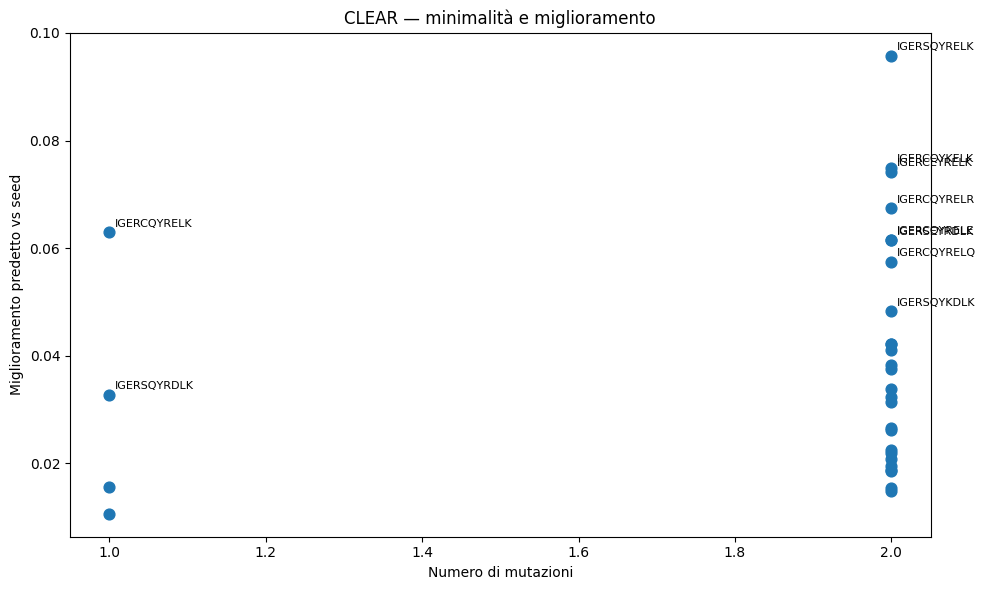

In [45]:
if not final_ranking.empty:
    plot_df = final_ranking.head(
        min(30, len(final_ranking))
    ).copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(
        plot_df["n_mutations"],
        plot_df[
            "predicted_improvement_vs_seed"
        ],
        s=60,
    )

    for row in plot_df.head(10).itertuples(index=False):
        plt.annotate(
            row.sequence,
            (
                row.n_mutations,
                row.predicted_improvement_vs_seed,
            ),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )

    plt.xlabel("Numero di mutazioni")
    plt.ylabel("Miglioramento predetto vs seed")
    plt.title("CLEAR — minimalità e miglioramento")
    plt.tight_layout()
    plt.savefig(
        REPORT_DIR
        / "clear_minimality_vs_improvement.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

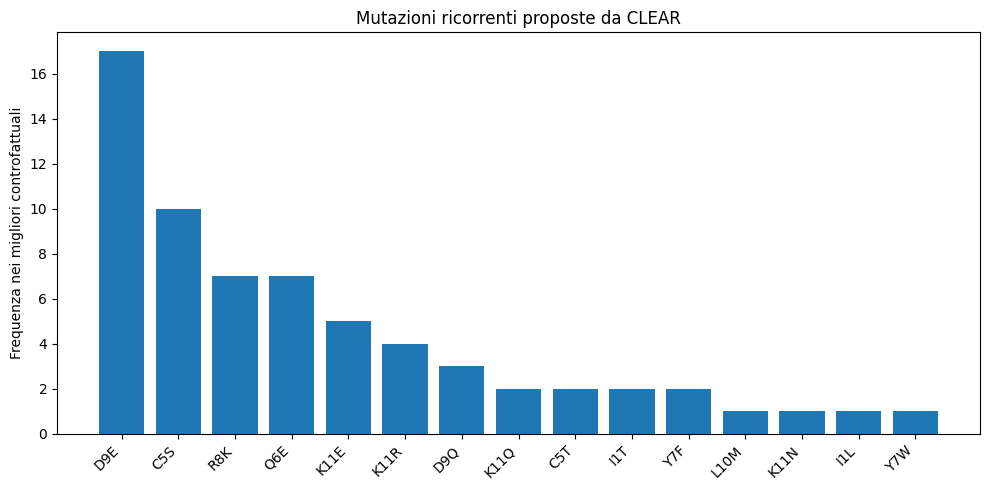

In [46]:
if not mutation_frequency.empty:
    plot_mutations = mutation_frequency.head(15)

    plt.figure(figsize=(10, 5))
    plt.bar(
        plot_mutations["mutation"],
        plot_mutations[
            "count_in_top_candidates"
        ],
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Frequenza nei migliori controfattuali")
    plt.title("Mutazioni ricorrenti proposte da CLEAR")
    plt.tight_layout()
    plt.savefig(
        REPORT_DIR
        / "clear_mutation_frequencies.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 20. Controlli finali


In [47]:
if final_ranking.empty:
    print(
        "Nessun controfattuale supera la soglia minima. "
        "Non procedere alla validazione senza rivedere "
        "target o soglia."
    )
else:
    assert final_ranking[
        "n_mutations"
    ].le(MAX_MUTATIONS).all()

    assert final_ranking[
        "predicted_improvement_vs_seed"
    ].ge(
        MIN_PREDICTED_IMPROVEMENT
    ).all()

    for sequence in final_ranking["sequence"]:
        valid, status = sequence_is_valid(sequence)

        if not valid:
            raise RuntimeError(
                f"Sequenza non valida: {sequence} — {status}"
            )

    print("Tutti i candidati finali rispettano i vincoli.")

print(
    "Candidati finali:",
    len(final_ranking),
)
print(
    "Candidati nuovi finali:",
    int(
        final_ranking[
            "is_novel_sequence"
        ].sum()
    )
    if not final_ranking.empty
    else 0,
)
print(
    "Pannello di validazione:",
    len(validation_panel),
)

Tutti i candidati finali rispettano i vincoli.
Candidati finali: 36
Candidati nuovi finali: 1
Pannello di validazione: 10


## 21. Esportazione finale


In [48]:
ALL_CANDIDATES_CSV = (
    CLEAR_DIR
    / "clear_all_counterfactual_candidates.csv"
)
FINAL_RANKING_CSV = (
    CLEAR_DIR
    / "clear_counterfactual_final_ranking.csv"
)
VALIDATION_PANEL_CSV = (
    VALIDATION_DIR
    / "clear_counterfactual_validation_panel.csv"
)
MUTATION_FREQUENCY_CSV = (
    CLEAR_DIR
    / "clear_mutation_frequency.csv"
)
RUN_CONFIG_JSON = (
    CLEAR_DIR
    / "clear_run_config.json"
)

all_candidates.to_csv(
    ALL_CANDIDATES_CSV,
    index=False,
)
final_ranking.to_csv(
    FINAL_RANKING_CSV,
    index=False,
)
validation_panel.to_csv(
    VALIDATION_PANEL_CSV,
    index=False,
)
mutation_frequency.to_csv(
    MUTATION_FREQUENCY_CSV,
    index=False,
)

run_config = {
    "seed_sequence": SEED_SEQUENCE,
    "seed_prediction": seed_prediction,
    "target_column": TARGET_COLUMN,
    "higher_is_better": HIGHER_IS_BETTER,
    "max_mutations": MAX_MUTATIONS,
    "min_predicted_improvement": (
        MIN_PREDICTED_IMPROVEMENT
    ),
    "n_restarts": N_RESTARTS,
    "optimization_steps": OPTIMIZATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "temperature_start": TEMPERATURE_START,
    "temperature_end": TEMPERATURE_END,
    "lambda_distance": LAMBDA_DISTANCE,
    "lambda_entropy": LAMBDA_ENTROPY,
    "beam_width": BEAM_WIDTH,
    "n_unique_candidates": len(all_candidates),
    "n_successful_counterfactuals": len(
        final_ranking
    ),
    "n_novel_successful": int(
        final_ranking[
            "is_novel_sequence"
        ].sum()
    )
    if not final_ranking.empty
    else 0,
    "n_validation_panel": len(
        validation_panel
    ),
    "warning": (
        "Predictions are surrogate-model hypotheses. "
        "Candidates require FoldX and Rosetta validation."
    ),
}

RUN_CONFIG_JSON.write_text(
    json.dumps(run_config, indent=2),
    encoding="utf-8",
)

for path in [
    ALL_CANDIDATES_CSV,
    FINAL_RANKING_CSV,
    VALIDATION_PANEL_CSV,
    MUTATION_FREQUENCY_CSV,
    RUN_CONFIG_JSON,
]:
    print("Salvato:", path.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/clear_all_counterfactual_candidates.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/clear_counterfactual_final_ranking.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/validation_panel/clear_counterfactual_validation_panel.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/clear_mutation_frequency.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/clear_run_config.json


## 22. Report automatico


In [49]:
best_row = (
    final_ranking.iloc[0]
    if not final_ranking.empty
    else None
)

report = f'''# 04e — CLEAR peptide counterfactual report

## Seed
- Sequenza: `{SEED_SEQUENCE}`
- Predizione dell'oracolo: {seed_prediction:.6f}
- Target: `{TARGET_COLUMN}`
- Higher is better: {HIGHER_IS_BETTER}

## Configurazione
- Mutazioni massime: {MAX_MUTATIONS}
- Restart soft: {N_RESTARTS}
- Step per restart: {OPTIMIZATION_STEPS}
- Beam width: {BEAM_WIDTH}
- Miglioramento minimo: {MIN_PREDICTED_IMPROVEMENT}

## Risultati
- Candidati unici: {len(all_candidates)}
- Controfattuali di successo: {len(final_ranking)}
- Controfattuali nuovi: {int(final_ranking["is_novel_sequence"].sum()) if not final_ranking.empty else 0}
- Pannello di validazione: {len(validation_panel)}

## Miglior candidato
- Sequenza: `{best_row["sequence"] if best_row is not None else "N/A"}`
- Mutazioni: {best_row["mutation_labels"] if best_row is not None else "N/A"}
- Predizione: {best_row["prediction"] if best_row is not None else float("nan"):.6f}
- Miglioramento predetto: {best_row["predicted_improvement_vs_seed"] if best_row is not None else float("nan"):.6f}
- Nuovo rispetto al 04c: {bool(best_row["is_novel_sequence"]) if best_row is not None else "N/A"}

## Output principali
- `{FINAL_RANKING_CSV}`
- `{VALIDATION_PANEL_CSV}`

## Interpretazione
I risultati sono controfattuali secondo la GNN del 04d. Non costituiscono una validazione energetica autonoma.

## Passaggio successivo
Eseguire FoldX BuildModel sul pannello esportato, ricalcolare contatti e clash, quindi sottoporre i migliori candidati a FlexPepDock.
'''

REPORT_PATH = (
    REPORT_DIR / "04e_clear_report.md"
)
REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("Report salvato:", REPORT_PATH.resolve())

# 04e — CLEAR peptide counterfactual report

## Seed
- Sequenza: `IGERCQYRDLK`
- Predizione dell'oracolo: 0.745930
- Target: `oracle_target_composite_preliminary`
- Higher is better: True

## Configurazione
- Mutazioni massime: 2
- Restart soft: 40
- Step per restart: 300
- Beam width: 80
- Miglioramento minimo: 0.005

## Risultati
- Candidati unici: 672
- Controfattuali di successo: 36
- Controfattuali nuovi: 1
- Pannello di validazione: 10

## Miglior candidato
- Sequenza: `IGERSQYRELK`
- Mutazioni: C5S;D9E
- Predizione: 0.841685
- Miglioramento predetto: 0.095755
- Nuovo rispetto al 04c: False

## Output principali
- `outputs/clear_peptide_counterfactuals_04e/clear_counterfactual_final_ranking.csv`
- `outputs/clear_peptide_counterfactuals_04e/validation_panel/clear_counterfactual_validation_panel.csv`

## Interpretazione
I risultati sono controfattuali secondo la GNN del 04d. Non costituiscono una validazione energetica autonoma.

## Passaggio successivo
Eseguire FoldX BuildModel su

## 23. Output principali

```text
outputs/clear_peptide_counterfactuals_04e/
    clear_all_counterfactual_candidates.csv
    clear_counterfactual_final_ranking.csv
    clear_mutation_frequency.csv
    clear_run_config.json

    validation_panel/
        clear_counterfactual_validation_panel.csv
        clear_validation_individual_list.txt

    reports/
        04e_clear_report.md
        clear_minimality_vs_improvement.png
        clear_mutation_frequencies.png
```

## Passaggio successivo consigliato

Creare un notebook di validazione:

```text
05c_CLEAR_Counterfactual_FoldX_and_Structural_Validation.ipynb
```

che:

1. costruisca i modelli FoldX del pannello;
2. confronti ΔΔG, contatti, hotspot e clash con F0010;
3. selezioni 3–5 candidati;
4. prepari il successivo refinement Rosetta.
